In [1]:
import pandas as pd #  pandas
import numpy as np # numpy
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint para visualización metadatos
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import seaborn as sns # seaborn
import statsmodels.api as sm #statsmodels
from sklearn.model_selection import train_test_split # para dividir los datos en train y test
from sklearn.preprocessing import StandardScaler, LabelEncoder # para estandarizar los datos
from sklearn.linear_model import LogisticRegression # RL
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # informes de resultados
from sklearn.model_selection import GridSearchCV # para grid search
from sklearn.tree import DecisionTreeClassifier # DT
from sklearn.ensemble import RandomForestClassifier # RF
from sklearn.neighbors import KNeighborsClassifier #kNN
from sklearn.svm import SVC # SVC
from sklearn.naive_bayes import GaussianNB # GNß
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA
from sklearn.metrics import recall_score # recall
from sklearn.neural_network import MLPClassifier # MLP
import shap # SHAP
import lime
from lime import lime_tabular # LIME
import xgboost as xgb # xgboost

# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def analizar_tarea(df, num_tarea): # función analizar_tarea
    """
    Analiza una tarea específica (1-25)
    """
    suffix = str(num_tarea) # sufijo
    
    # --- FILTRADO ---
    # Se buscan las columnas que terminen en el número de tarea, 
    # IMPORTANTO: se asegura que el número anterior NO sea otro dígito.
    cols_tarea = [] # lista vacia
    for col in df.columns: # se recorren las columnas
        if col.endswith(suffix): # cuando la col acaba en el sufijo
            # Verificamos el prefijo del número para no confundir 1 con 11, 21...
            posible_prefijo = col[:-(len(suffix))] # prefijo
            # si el último caracter del prefijo no es un número se añade
            if not posible_prefijo[-1:].isdigit(): 
                cols_tarea.append(col)

    if not cols_tarea: # si no se encuentran columnas con el sufijo dado
        print(f"No se encontraron columnas para la tarea {num_tarea}")
        return None

    print(f"Analizando Tarea {num_tarea} ({len(cols_tarea)} variables)")

    # Crear un subset con las variables de la tarea + la clase
    df_tarea = df[cols_tarea + ['class']].copy()

    print(f"Tarea {num_tarea} extraída: {len(cols_tarea)} variables + 'class'.")
    return df_tarea

    # --- EJECUCIÓN ---
df_1 = analizar_tarea(df, 1)
df_2 = analizar_tarea(df, 2)
df_3 = analizar_tarea(df, 3)
df_4 = analizar_tarea(df, 4)
df_5 = analizar_tarea(df, 5)
df_6 = analizar_tarea(df, 6)
df_7 = analizar_tarea(df, 7)
df_8 = analizar_tarea(df, 8)
df_9 = analizar_tarea(df, 9)
df_10 = analizar_tarea(df, 10)
df_11 = analizar_tarea(df, 11)
df_12 = analizar_tarea(df, 12)
df_13 = analizar_tarea(df, 13)
df_14 = analizar_tarea(df, 14)
df_15 = analizar_tarea(df, 15)
df_16 = analizar_tarea(df, 16)
df_17 = analizar_tarea(df, 17)
df_18 = analizar_tarea(df, 18)
df_19 = analizar_tarea(df, 19)
df_20 = analizar_tarea(df, 20)
df_21 = analizar_tarea(df, 21)
df_22 = analizar_tarea(df, 22)
df_23 = analizar_tarea(df, 23)
df_24 = analizar_tarea(df, 24)
df_25 = analizar_tarea(df, 25)

Analizando Tarea 1 (18 variables)
Tarea 1 extraída: 18 variables + 'class'.
Analizando Tarea 2 (18 variables)
Tarea 2 extraída: 18 variables + 'class'.
Analizando Tarea 3 (18 variables)
Tarea 3 extraída: 18 variables + 'class'.
Analizando Tarea 4 (18 variables)
Tarea 4 extraída: 18 variables + 'class'.
Analizando Tarea 5 (18 variables)
Tarea 5 extraída: 18 variables + 'class'.
Analizando Tarea 6 (18 variables)
Tarea 6 extraída: 18 variables + 'class'.
Analizando Tarea 7 (18 variables)
Tarea 7 extraída: 18 variables + 'class'.
Analizando Tarea 8 (18 variables)
Tarea 8 extraída: 18 variables + 'class'.
Analizando Tarea 9 (18 variables)
Tarea 9 extraída: 18 variables + 'class'.
Analizando Tarea 10 (18 variables)
Tarea 10 extraída: 18 variables + 'class'.
Analizando Tarea 11 (18 variables)
Tarea 11 extraída: 18 variables + 'class'.
Analizando Tarea 12 (18 variables)
Tarea 12 extraída: 18 variables + 'class'.
Analizando Tarea 13 (18 variables)
Tarea 13 extraída: 18 variables + 'class'.
Anal

In [17]:
# Se elimina la columna ID
# X = df (sin 'ID' ni 'class'), axis = 1 para cols
X = df_12.drop(['class'], axis = 1)

# Y contiene 'class'
Y = df_12['class']

# Se codficia paciente (P) -> 1 y sano (H) -> 0
le = LabelEncoder()
Y = le.fit_transform(Y)

# Se dividen los datos en 80% para train y 20% para test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Se revisa la correcta división de los datos
print(f"Datos de entrenamiento {len(X_train)}")
print(f"Datos test {len(X_test)}")

Datos de entrenamiento 139
Datos test 35


In [18]:
# StandardScaler()
scaler = StandardScaler()

# Se ajusta la estandarización con X_train
X_train_scaled = scaler.fit_transform(X_train)

# Se aplica la transformación al test
X_test_scaled = scaler.transform(X_test)

# ANÁLISIS DE ML 4

## DECISION TREE

In [19]:
# Se crea el modelo
tree_model = DecisionTreeClassifier(random_state=42) # random state para replicabilidad

# Se entrena el modelo
tree_model.fit(X_train_scaled, Y_train)

# Se realizan las predicciones
Y_pred_dt = tree_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_dt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_dt))

# TP; TN; FP; FN
tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(Y_test, Y_pred_dt).ravel()

sensitivity_dt = tp_dt / (tp_dt + fn_dt) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_dt / (tn_dt + fp_dt) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.56      0.50      0.53        18

    accuracy                           0.54        35
   macro avg       0.54      0.54      0.54        35
weighted avg       0.54      0.54      0.54        35

--- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 9  9]]
Sensibilidad: 0.50
Especificidad: 0.59


In [20]:
# max depth
max_depth_range = np.arange(2, 11, 1)

# min samples split
min_samples_split_range = np.arange(2, 6, 1)

# min samples leaf
min_samples_leaf_range = np.arange(2, 22, 2) 

param_grid_dt = {
    'max_depth': max_depth_range,
    'min_samples_split': min_samples_split_range,
    'min_samples_leaf': min_samples_leaf_range
}

# Buscador
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

# Se entrena el modelo
grid_dt.fit(X_train_scaled, Y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_dt.best_params_}")
print(f"Mejor accuracy en CV: {grid_dt.best_score_}")

# Mejor árbol
best_tree = grid_dt.best_estimator_

# Resultados
Y_pred_opt = best_tree.predict(X_test_scaled)

print("--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_opt))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_opt))

# Sensibilidad y especificidad
tn_dt2, fp_dt2, fn_dt2, tp_dt2 = confusion_matrix(Y_test, Y_pred_opt).ravel()

print(f"Sensibilidad: {tp_dt2 / (tp_dt2 + fn_dt2):.2f}")
print(f"Especificidad: {tn_dt2 / (tn_dt2 + fp_dt2):.2f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejor combinación: {'max_depth': np.int64(3), 'min_samples_leaf': np.int64(12), 'min_samples_split': np.int64(2)}
Mejor accuracy en CV: 0.734126984126984
--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.50      0.59      0.54        17
           1       0.53      0.44      0.48        18

    accuracy                           0.51        35
   macro avg       0.52      0.52      0.51        35
weighted avg       0.52      0.51      0.51        35

--- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [10  8]]
Sensibilidad: 0.44
Especificidad: 0.59


**SHAP**

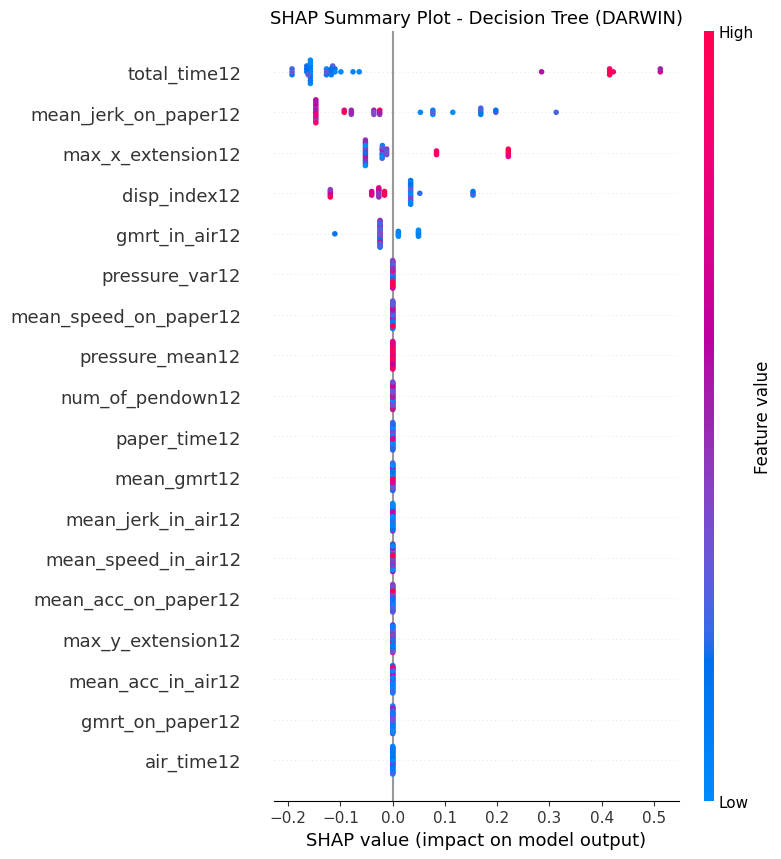

✔ Summary plot guardado.


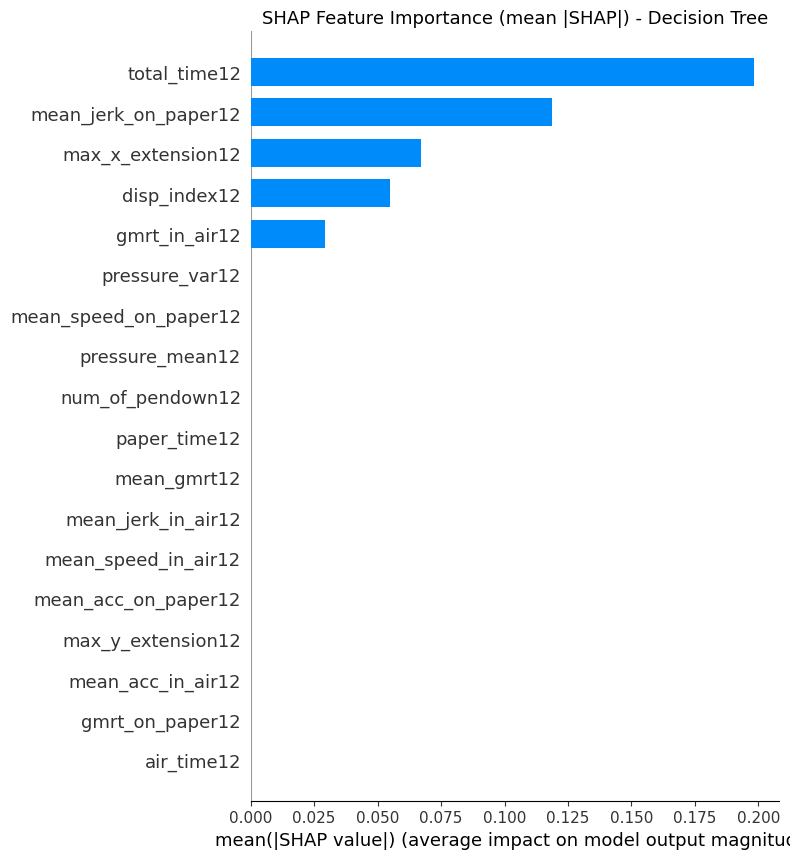

✔ Bar plot guardado.


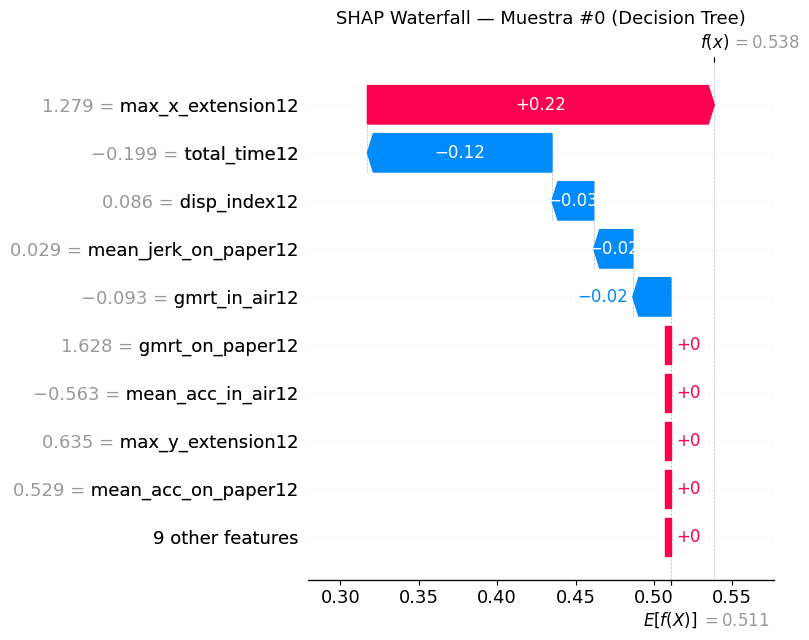

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

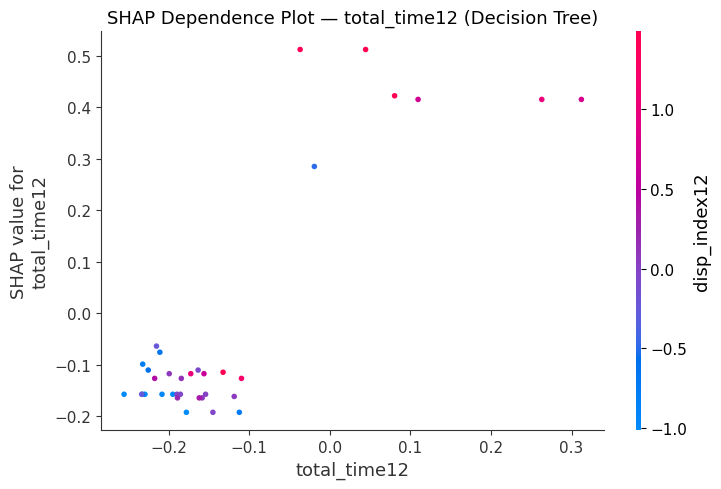

✔ Dependence plot guardado para: total_time12

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===
             Feature  Mean |SHAP|
        total_time12     0.198237
mean_jerk_on_paper12     0.118662
   max_x_extension12     0.067094
        disp_index12     0.054792
       gmrt_in_air12     0.029107
          air_time12     0.000000
   mean_acc_in_air12     0.000000
 mean_acc_on_paper12     0.000000
     gmrt_on_paper12     0.000000
   max_y_extension12     0.000000


In [21]:
# ============================================================
# ANÁLISIS SHAP PARA DECISION TREE
# ============================================================

# Explainer
explainer_dt = shap.TreeExplainer(best_tree) # best_tree o tree_model
 
# SHAP values
shap_values_dt = explainer_dt.shap_values(X_test_scaled)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv = np.array(shap_values_dt)[:, :, 1]  # shape (35, 450)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Decision Tree (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Decision Tree", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 0

explanation_dt = shap.Explanation(
    values=sv[sample_idx],
    base_values=explainer_dt.expected_value[1],
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_dt, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)
top_feature_idx_dt = np.argmax(mean_abs_shap_dt)
top_feature_name_dt = X.columns[top_feature_idx_dt]

plt.figure()
shap.dependence_plot(
    top_feature_idx_dt,
    sv,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_dt} (Decision Tree)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dt_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_dt}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
mean_abs_shap_dt = np.abs(sv).mean(axis=0)

feature_importance_dt_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_dt
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Decision Tree) ===")
print(feature_importance_dt_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 0 ---
Clase real     : 0
Clase predicha : 1
Probabilidades : H=0.462 | P=0.538

Top features (peso LIME):
  max_x_extension12 > 0.31                       +0.1638
  -0.21 < total_time12 <= -0.16                  -0.1390
  -0.18 < mean_jerk_on_paper12 <= 0.64           -0.1382
  -0.16 < disp_index12 <= 0.45                   -0.0542
  -0.25 < gmrt_in_air12 <= 0.09                  -0.0216
  -0.27 < mean_speed_in_air12 <= 0.32            -0.0169
  max_y_extension12 > 0.44                       +0.0163
  mean_gmrt12 > 0.16                             +0.0161
  -0.67 < num_of_pendown12 <= -0.37              -0.0136
  -0.49 < mean_jerk_in_air12 <= -0.37            +0.0116
  0.40 < pressure_mean12 <= 0.68                 -0.0096
  -0.10 < mean_acc_on_paper12 <= 0.68            +0.0096
  gmrt_on_paper12 > 0.55                         +0.0093
  mean_speed_on_paper12 > 0.55                   +0.0065
  -0.59 < paper_time12 <= -0.33                  +0.0057


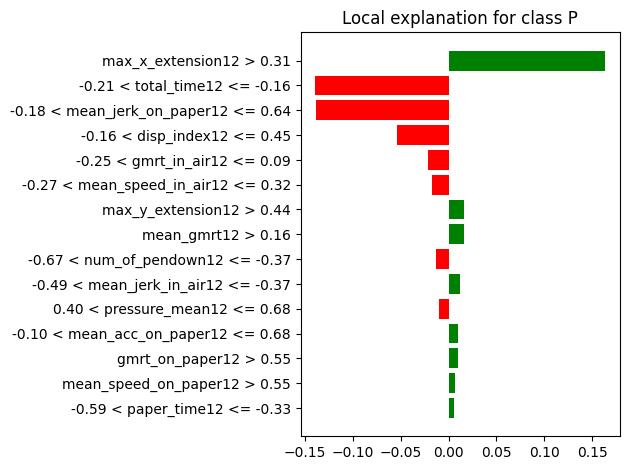


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. total_time12                              0.19502
   2. mean_jerk_on_paper12                      0.14591
   3. max_x_extension12                         0.08017
   4. disp_index12                              0.06923
   5. gmrt_in_air12                             0.03619
   6. mean_jerk_in_air12                        0.02496
   7. pressure_var12                            0.02128
   8. pressure_mean12                           0.02120
   9. mean_speed_on_paper12                     0.02065
  10. air_time12                                0.02061
  11. gmrt_on_paper12                           0.02003
  12. mean_acc_on_paper12                       0.01999
  13. paper_time12                              0.01934
  14. mean_speed_in_air12                       0.01904
  15. num_of_pendown12                          0.01902
  16. mean_acc_in_air12                         0.01900
  17. max_y_extensi

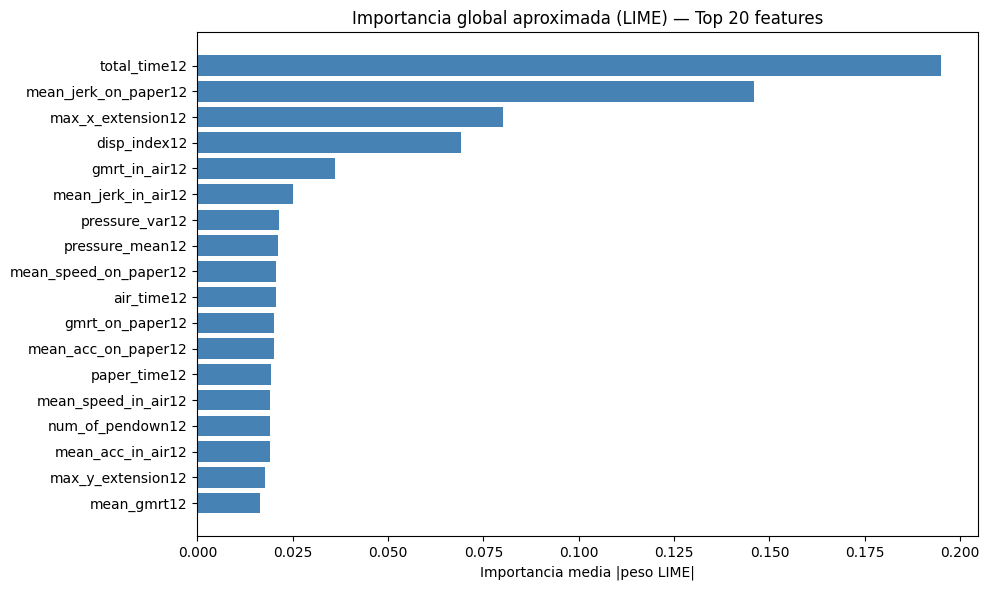

In [22]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 0
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = best_tree.predict_proba, # best_tree o tree_model
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_opt[INSTANCE_IDX]}") # Y_pred_opt Y_pred_dt
print(f"Probabilidades : H={best_tree.predict_proba([instance])[0][0]:.3f} | " # best
      f"P={best_tree.predict_proba([instance])[0][1]:.3f}")  # best
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = best_tree.predict_proba, # best
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## RANDOM FOREST

In [23]:
# Modelo
rf_model = RandomForestClassifier(n_estimators=100, # 100 árboles
                                  random_state=42) # resultados reproducibles

# Se entrena el modelo
rf_model.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_rf = rf_model.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN: ---") # informe de clasificación
print(classification_report(Y_test, Y_pred_rf))

# Matriz de confusión
print(" --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf))

# Sensibilidad y especificidad
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(Y_test, Y_pred_rf).ravel()

print(f"Sensibilidad: {tp_rf / (tp_rf + fn_rf):.2f}")
print(f"Especificidad: {tn_rf / (tn_rf + fp_rf):.2f}")

 --- INFORME DE CLASIFICACIÓN: ---
              precision    recall  f1-score   support

           0       0.56      0.59      0.57        17
           1       0.59      0.56      0.57        18

    accuracy                           0.57        35
   macro avg       0.57      0.57      0.57        35
weighted avg       0.57      0.57      0.57        35

 --- MATRIZ DE CONFUSIÓN ---
[[10  7]
 [ 8 10]]
Sensibilidad: 0.56
Especificidad: 0.59


In [24]:
# Se define el Grid 
param_grid_rf = {
    'max_depth': np.arange(3, 11, 1),           # 3 a 10 (step 1)
    'n_estimators': np.arange(100, 350, 50),    # 100 a 300 
    'bootstrap': [True, False],                 # true y False
    'min_samples_split': [2],                   
    'min_samples_leaf': [1]
}                  

# Se configura el buscador
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Se entrena buscando la mejor combinación
grid_rf.fit(X_train_scaled, Y_train)

# Mejor modelo 
best_rf = grid_rf.best_estimator_
#print(f"Mejores parámetros: {grid_rf.best_params_}")

# Se realizan las predicciones
Y_pred_rf2 = best_rf.predict(X_test_scaled)

print("--- INFORME CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_rf2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_rf2))

# Sensibilidad y especificidad
tn_rf2, fp_rf2, fn_rf2, tp_rf2 = confusion_matrix(Y_test, Y_pred_rf2).ravel()

print(f"Sensibilidad: {tp_rf2 / (tp_rf2 + fn_rf2):.2f}")
print(f"Especificidad: {tn_rf2 / (tn_rf2 + fp_rf2):.2f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits


--- INFORME CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.55      0.65      0.59        17
           1       0.60      0.50      0.55        18

    accuracy                           0.57        35
   macro avg       0.57      0.57      0.57        35
weighted avg       0.58      0.57      0.57        35

--- MATRIZ DE CONFUSIÓN ---
[[11  6]
 [ 9  9]]
Sensibilidad: 0.50
Especificidad: 0.65


**SHAP**

Shape shap_values_rf: (35, 18, 2)
Shape sv_rf: (35, 18)


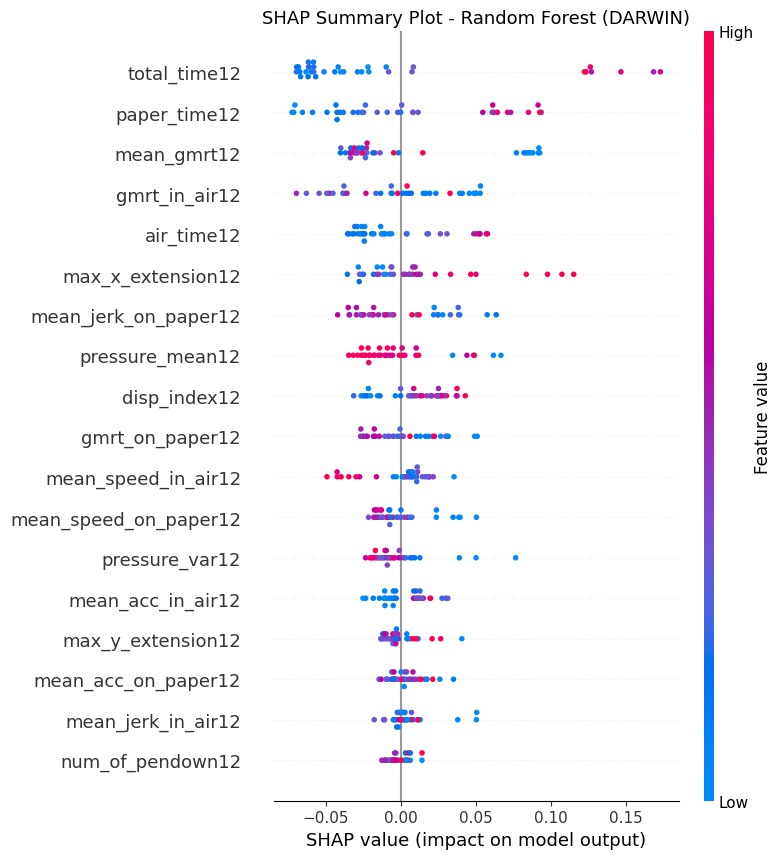

✔ Summary plot guardado.


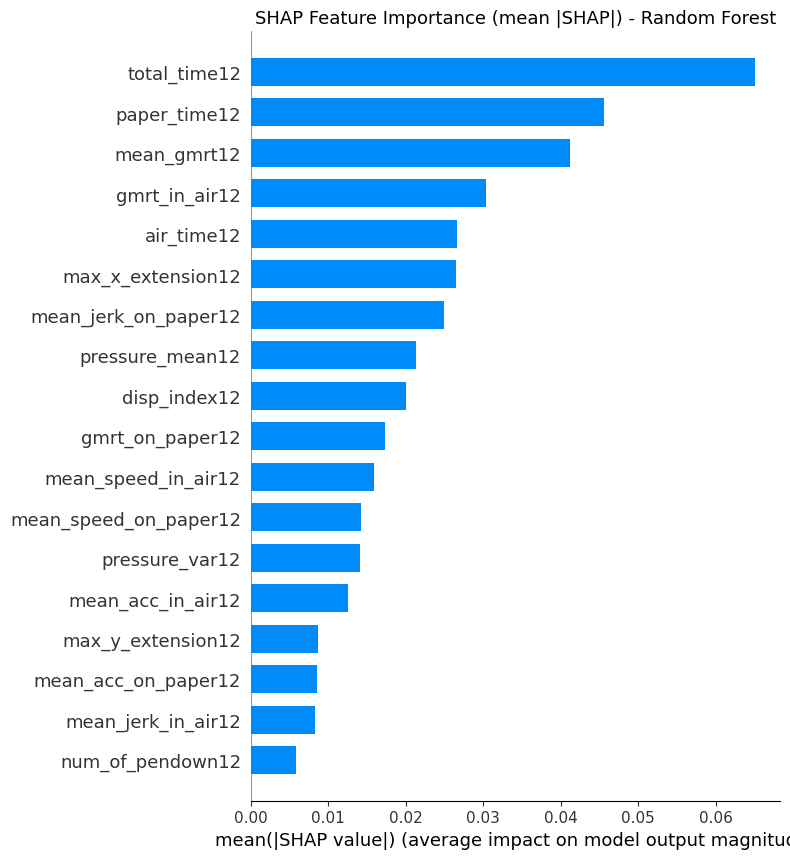

✔ Bar plot guardado.
expected_value_rf: [0.49093525 0.50906475]


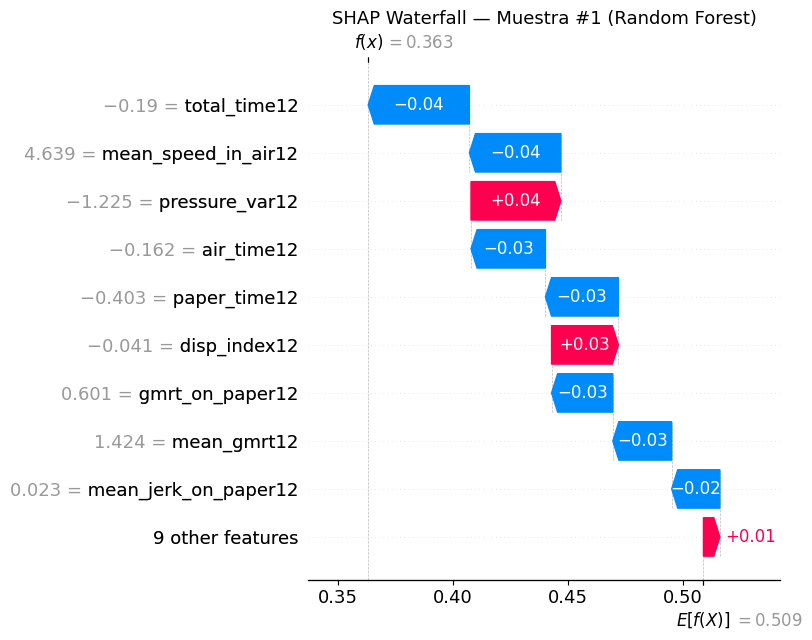

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

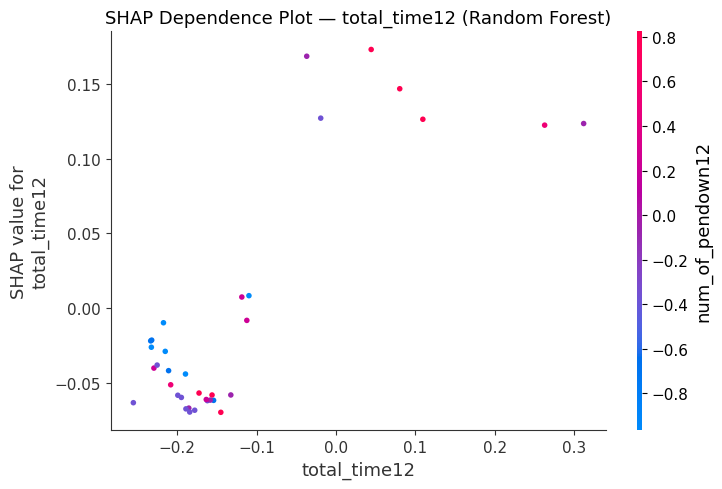

✔ Dependence plot guardado para: total_time12

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===
             Feature  Mean |SHAP|
        total_time12     0.065042
        paper_time12     0.045614
         mean_gmrt12     0.041216
       gmrt_in_air12     0.030371
          air_time12     0.026591
   max_x_extension12     0.026469
mean_jerk_on_paper12     0.024939
     pressure_mean12     0.021376
        disp_index12     0.020070
     gmrt_on_paper12     0.017285


In [25]:
# ============================================================
# ANÁLISIS SHAP PARA RANDOM FOREST
# ============================================================

# Explainer
explainer_rf = shap.TreeExplainer(best_rf) # rf_model o best_rf

# SHAP values
shap_values_rf = explainer_rf.shap_values(X_test_scaled)

# Verificar estructura (por consistencia con tu entorno)
print("Shape shap_values_rf:", np.array(shap_values_rf).shape)

# Extraer clase positiva (Parkinson) — estructura (n_muestras, n_features, n_clases)
sv_rf = np.array(shap_values_rf)[:, :, 1]  # shape (35, 450)
print("Shape sv_rf:", sv_rf.shape)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - Random Forest (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global
# ============================================================
plt.figure()
shap.summary_plot(
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - Random Forest", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# ============================================================
sample_idx = 1

# Verificar expected_value
print("expected_value_rf:", explainer_rf.expected_value)

explanation_rf = shap.Explanation(
    values=sv_rf[sample_idx],
    base_values=explainer_rf.expected_value[1],  # si es escalar → quitar [1]
    data=X_test_scaled[sample_idx],
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_rf, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# ============================================================
mean_abs_shap_rf = np.abs(sv_rf).mean(axis=0)
top_feature_idx_rf = np.argmax(mean_abs_shap_rf)
top_feature_name_rf = X.columns[top_feature_idx_rf]

plt.figure()
shap.dependence_plot(
    top_feature_idx_rf,
    sv_rf,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name_rf} (Random Forest)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_rf_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name_rf}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features
# ============================================================
feature_importance_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap_rf
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP - Random Forest) ===")
print(feature_importance_rf_df.head(10).to_string(index=False))

**LIME**


--- LIME: instancia 0 ---
Clase real     : 0
Clase predicha : 1
Probabilidades : H=0.548 | P=0.452
  max_x_extension12 > 0.31                       +0.0719
  -0.21 < total_time12 <= -0.16                  -0.0700
  -0.59 < paper_time12 <= -0.33                  -0.0421
  -0.18 < mean_jerk_on_paper12 <= 0.64           -0.0349
  mean_gmrt12 > 0.16                             -0.0238
  0.40 < pressure_mean12 <= 0.68                 -0.0212
  -0.16 < disp_index12 <= 0.45                   +0.0201
  -0.17 < air_time12 <= -0.16                    -0.0170
  -0.25 < gmrt_in_air12 <= 0.09                  -0.0165
  mean_acc_in_air12 <= -0.50                     -0.0143
  max_y_extension12 > 0.44                       +0.0133
  -0.27 < mean_speed_in_air12 <= 0.32            +0.0114
  mean_speed_on_paper12 > 0.55                   -0.0107
  -0.67 < num_of_pendown12 <= -0.37              -0.0100
  -0.10 < mean_acc_on_paper12 <= 0.68            +0.0098


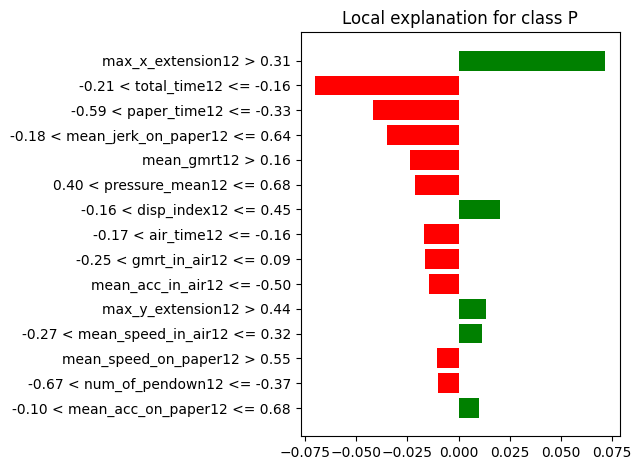


Calculando importancia global LIME...

Top-20 features por importancia global LIME:
   1. total_time12                              0.06523
   2. paper_time12                              0.04830
   3. max_x_extension12                         0.03699
   4. mean_gmrt12                               0.03587
   5. mean_jerk_on_paper12                      0.02726
   6. gmrt_in_air12                             0.02719
   7. gmrt_on_paper12                           0.02394
   8. pressure_mean12                           0.02264
   9. mean_speed_on_paper12                     0.02262
  10. disp_index12                              0.02044
  11. mean_speed_in_air12                       0.02040
  12. air_time12                                0.02008
  13. mean_acc_in_air12                         0.01413
  14. num_of_pendown12                          0.01318
  15. max_y_extension12                         0.01296
  16. pressure_var12                            0.01294
  17. mean_acc_on_p

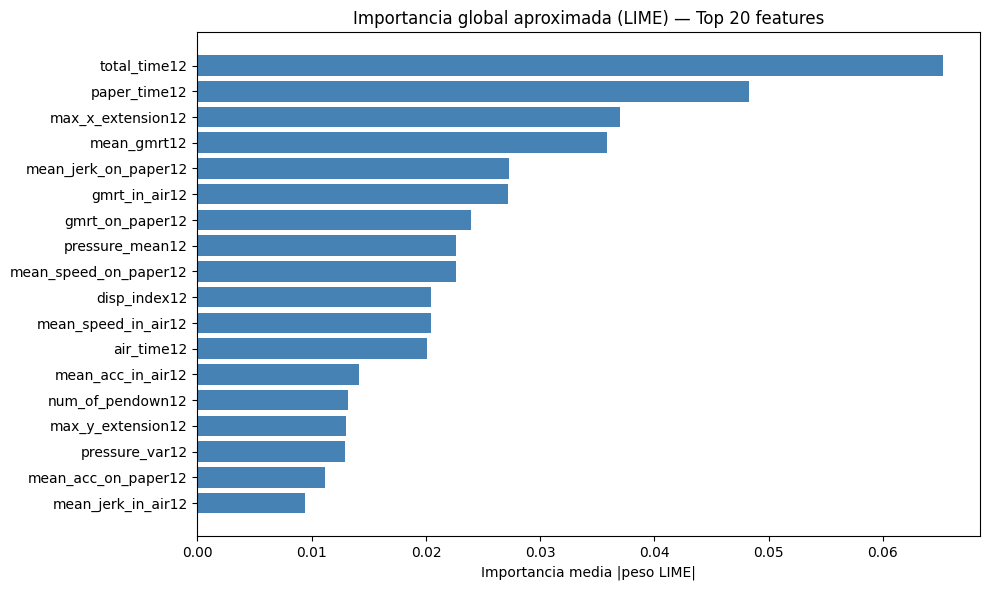

In [26]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO RF
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 0
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = rf_model.predict_proba, # rf_model best_rf
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_rf[INSTANCE_IDX]}") # Y_pred_rf Y_pred_rf2
print(f"Probabilidades : H={best_rf.predict_proba([instance])[0][0]:.3f} | " # rf_model best_rf
      f"P={best_rf.predict_proba([instance])[0][1]:.3f}") # best
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = rf_model.predict_proba, # rf_model
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME:")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="steelblue")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — Top 20 features")
plt.tight_layout()
plt.show()

## XGBOOST

In [27]:
# Modelo
modelo_xgb = xgb.XGBClassifier(
    n_estimators = 100, # nº árboles
    learning_rate = 0.1, # paso de aprendizaje
    max_depth = 3, # profundidad árboles
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb))

# TP; TN; FP; FN
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(Y_test, Y_pred_xgb).ravel()

sensitivity_xgb = tp_xgb / (tp_xgb + fn_xgb) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_xgb = tn_xgb / (tn_xgb + fp_xgb) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        17
           1       0.50      0.50      0.50        18

    accuracy                           0.49        35
   macro avg       0.49      0.49      0.49        35
weighted avg       0.49      0.49      0.49        35

--- MATRIZ DE CONFUSIÓN ---
[[8 9]
 [9 9]]
Sensibilidad: 0.50
Especificidad: 0.59


/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:34:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [28]:
# Modelo
modelo_xgb2 = xgb.XGBClassifier(
    n_estimators = 200, # nº árboles
    learning_rate = 0.05, # paso de aprendizaje
    max_depth = 4, # profundidad árboles
    gamma = 0.2, # reg para evitar ramas débiles
    subsample = 0.8, 
    colsample_bytree=0.8,
    scale_pos_weight=1.2,
    use_label_encoder = False,
    eval_metrics = 'logloss',
    base_score=0.5
)

# Se entrena
modelo_xgb2.fit(X_train_scaled, Y_train)

# Predicciones
Y_pred_xgb2 = modelo_xgb2.predict(X_test_scaled)

# Resultados
print(" --- INFORME DE CLASIFICACIÓN ---")
print(classification_report(Y_test, Y_pred_xgb2))

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(Y_test, Y_pred_xgb2))

# TP; TN; FP; FN
tn_xgb2, fp_xgb2, fn_xgb2, tp_xgb2 = confusion_matrix(Y_test, Y_pred_xgb2).ravel()

sensitivity_dt = tp_xgb2 / (tp_xgb2 + fn_xgb2) # sensibilidad
print(f"Sensibilidad: {sensitivity_dt:.2f}")

specificity_dt = tn_xgb2 / (tn_xgb2 + fp_xgb2) # especificidad
print(f"Especificidad: {specificity_dt:.2f}")

/opt/miniconda3/envs/tfm_env/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [21:34:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 --- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.50      0.53      0.51        17
           1       0.53      0.50      0.51        18

    accuracy                           0.51        35
   macro avg       0.51      0.51      0.51        35
weighted avg       0.52      0.51      0.51        35

--- MATRIZ DE CONFUSIÓN ---
[[9 8]
 [9 9]]
Sensibilidad: 0.50
Especificidad: 0.53


**SHAP**

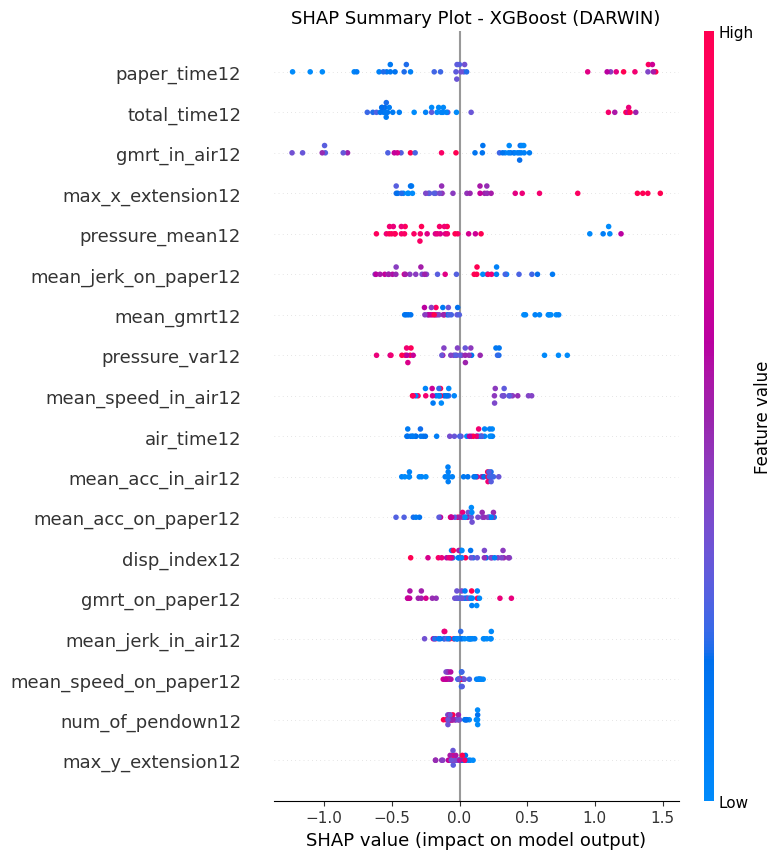

✔ Summary plot guardado.


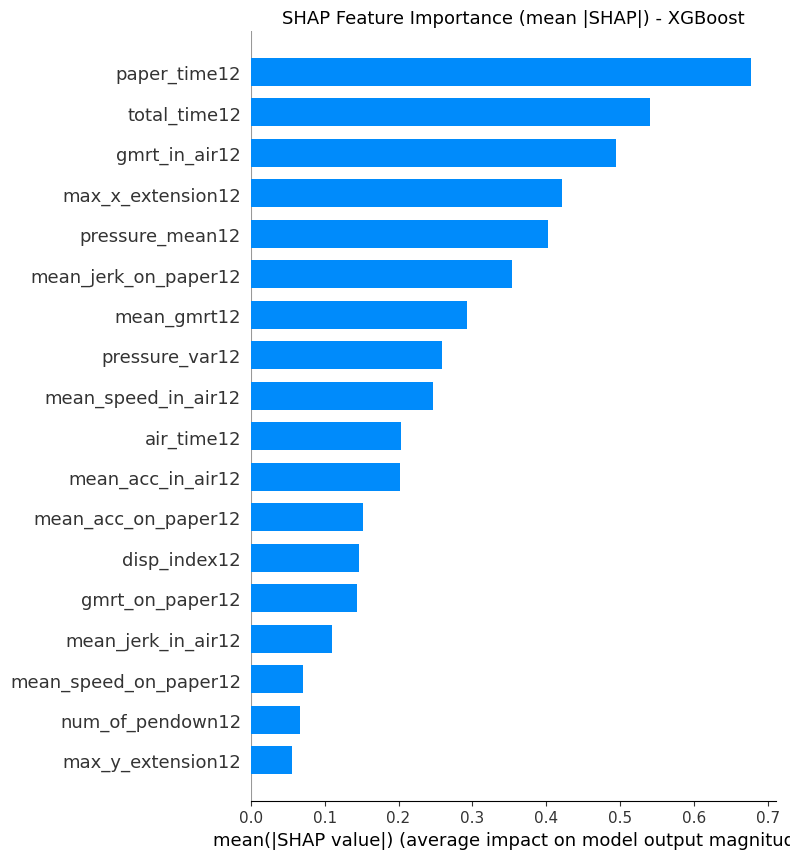

✔ Bar plot guardado.


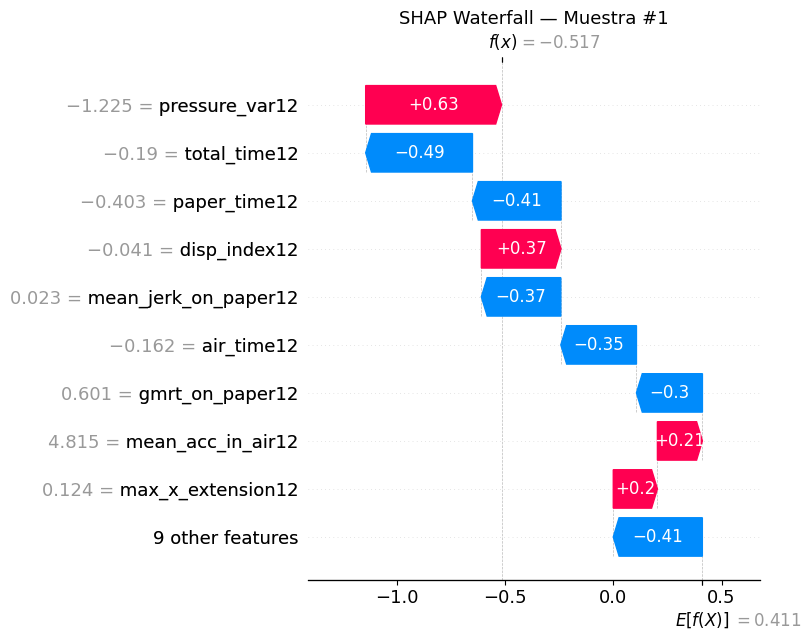

✔ Waterfall plot guardado.


<Figure size 640x480 with 0 Axes>

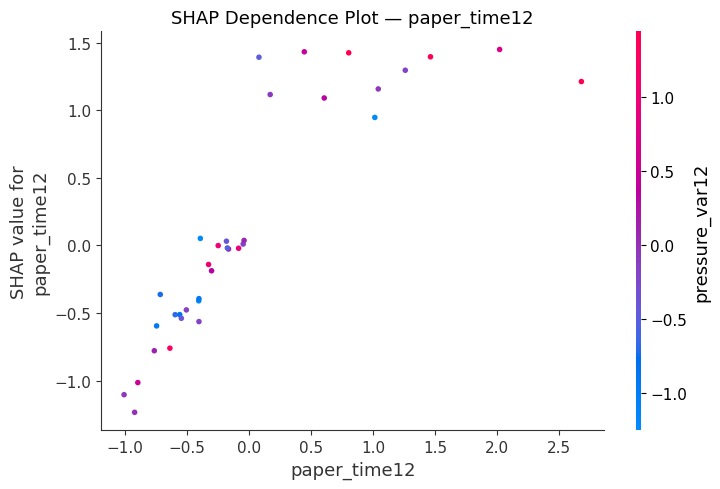

✔ Dependence plot guardado para: paper_time12

=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===
             Feature  Mean |SHAP|
        paper_time12     0.676937
        total_time12     0.540715
       gmrt_in_air12     0.494612
   max_x_extension12     0.420763
     pressure_mean12     0.402750
mean_jerk_on_paper12     0.353652
         mean_gmrt12     0.292961
      pressure_var12     0.258993
 mean_speed_in_air12     0.247217
          air_time12     0.203450


In [29]:
# ============================================================
# ANÁLISIS SHAP PARA XGBOOST
# ============================================================

# Explainer SHAP (TreeExplainer es el óptimo para XGBoost)
explainer = shap.TreeExplainer(modelo_xgb2) # 2

# Calcular los SHAP values sobre el test set
shap_values = explainer.shap_values(X_test_scaled)

# ============================================================
# PLOT 1: Summary Plot (Beeswarm)
# Muestra importancia + dirección del efecto de cada feature
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("SHAP Summary Plot - XGBoost (DARWIN)", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Summary plot guardado.")

# ============================================================
# PLOT 2: Bar Plot — Importancia media global (|SHAP|)
# ============================================================
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance (mean |SHAP|) - XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Bar plot guardado.")

# ============================================================
# PLOT 3: Waterfall Plot — Explicación individual
# Desglosa la predicción de una sola muestra
# ============================================================
# Índice de la muestra a explicar (cámbialo si quieres otra)
sample_idx = 1

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx] if hasattr(X_test_scaled, '__array__') else X_test_scaled.iloc[sample_idx].values,
    feature_names=X.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Muestra #{sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✔ Waterfall plot guardado.")

# ============================================================
# PLOT 4: Dependence Plot — Feature más importante
# Relación entre el valor de la feature y su SHAP value
# ============================================================
# Identificar la feature con mayor impacto medio
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argmax(mean_abs_shap)
top_feature_name = X.columns[top_feature_idx]

plt.figure()
shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature_name}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✔ Dependence plot guardado para: {top_feature_name}")

# ============================================================
# RESUMEN NUMÉRICO: Top 10 features por |SHAP| medio
# ============================================================
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\n=== TOP 10 FEATURES MÁS RELEVANTES (SHAP) ===")
print(feature_importance_df.head(10).to_string(index=False))

**LIME**

In [ ]:
# ─────────────────────────────────────────
# LIME - EXPLICABILIDAD DEL MODELO XGBoost
# ─────────────────────────────────────────

# Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X.columns.tolist(),
    class_names   = ["H", "P"],
    mode          = "classification",
    random_state  = 42
)

# ── Explicación individual (instancia 0) ──
INSTANCE_IDX = 1
instance = X_test_scaled[INSTANCE_IDX]

exp = explainer.explain_instance(
    data_row   = instance,
    predict_fn = modelo_xgb2.predict_proba, # modelo_xgb modelo_xgb2
    num_features = 15,
    num_samples  = 5000
)

print(f"\n--- LIME XGBoost: instancia {INSTANCE_IDX} ---")
print(f"Clase real     : {Y_test[INSTANCE_IDX]}")
print(f"Clase predicha : {Y_pred_xgb2[INSTANCE_IDX]}") # Y_pred_xgb Y_pred_xgb2
print(f"Probabilidades : H={modelo_xgb2.predict_proba([instance])[0][0]:.3f} | " # 2
      f"P={modelo_xgb2.predict_proba([instance])[0][1]:.3f}") # 2
print("\nTop features (peso LIME):")
for feat, weight in exp.as_list():
    print(f"  {feat:45s}  {weight:+.4f}")

fig = exp.as_pyplot_figure()
fig.tight_layout()
plt.show()

# ── Importancia global aproximada ──
print("\nCalculando importancia global LIME (XGBoost)...")

all_weights = {feat: [] for feat in X.columns}

for i in range(len(X_test_scaled)):
    exp_i = explainer.explain_instance(
        data_row     = X_test_scaled[i],
        predict_fn   = modelo_xgb2.predict_proba, # 2
        num_features = 15,
        num_samples  = 1000
    )
    for feat, weight in exp_i.as_list():
        for col in X.columns:
            if col in feat:
                all_weights[col].append(abs(weight))
                break

global_importance = {
    feat: np.mean(weights) if weights else 0.0
    for feat, weights in all_weights.items()
}

top_global = sorted(global_importance.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop-20 features por importancia global LIME (XGBoost):")
for rank, (feat, score) in enumerate(top_global, 1):
    print(f"  {rank:2d}. {feat:40s}  {score:.5f}")

feats, scores = zip(*top_global)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feats[::-1], scores[::-1], color="darkorange")
ax.set_xlabel("Importancia media |peso LIME|")
ax.set_title("Importancia global aproximada (LIME) — XGBoost — Top 20 features")
plt.tight_layout()
plt.show()


--- LIME XGBoost: instancia 1 ---
Clase real     : 1
Clase predicha : 0
Probabilidades : H=0.627 | P=0.373

Top features (peso LIME):
  -0.59 < paper_time12 <= -0.33                  -0.1300
  gmrt_in_air12 > 0.09                           -0.1294
  pressure_mean12 > 0.68                         -0.1201
  -0.18 < mean_jerk_on_paper12 <= 0.64           -0.1079
  pressure_var12 <= -0.64                        +0.1060
  -0.21 < total_time12 <= -0.16                  -0.0943
  -0.10 < mean_acc_on_paper12 <= 0.68            +0.0521
  mean_gmrt12 > 0.16                             -0.0491
  mean_acc_in_air12 > -0.05                      +0.0403
  -0.17 < air_time12 <= -0.16                    -0.0385
  -0.15 < max_x_extension12 <= 0.31              -0.0276
  mean_speed_on_paper12 > 0.55                   -0.0203
  -0.16 < disp_index12 <= 0.45                   +0.0195
  mean_jerk_in_air12 > -0.07                     -0.0177
  num_of_pendown12 <= -0.67                      +0.0135
